# Milestone 2 — Analisis ROI Film Global (2000–2023)

**Nama:** Rinaldi  
**Batch:** CODA-RMT-016

## Identifikasi Masalah

### Latar Belakang

Industri film global terus berkembang, namun tidak semua film berhasil menghasilkan keuntungan. Banyak film dengan budget besar justru tidak balik modal, sementara film dengan budget kecil mampu menghasilkan keuntungan berlipat ganda. Kondisi ini membuat investor kesulitan menentukan film seperti apa yang layak untuk diinvestasikan.

### Problem Statement

Menganalisis pengaruh genre, budget, dan production company terhadap ROI film di industri perfilman global periode 2000–2023, guna memberikan rekomendasi investasi berbasis data kepada investor film.

### Rumusan Masalah

1. Kapan tren ROI film mengalami peningkatan atau penurunan dalam beberapa tahun terakhir?
2. Bagaimana distribusi ROI film secara keseluruhan?
3. Production company mana yang secara konsisten menghasilkan film dengan ROI tinggi?
4. Genre film apa yang memiliki ROI tertinggi?
5. Apakah terdapat hubungan antara budget dengan ROI?
6. Apakah rata-rata ROI setiap genre berbeda secara signifikan?

### Disclaimer

- Data budget pada dataset yang digunakan tidak memiliki standar yang konsisten. Ada film yang hanya mencatat biaya produksi, ada juga yang sudah mencakup biaya marketing. Karena itu, nilai ROI yang dihitung tidak bisa dianggap sepenuhnya akurat — dalam analisis ini ROI digunakan sebagai gambaran umum untuk melihat tren dan membandingkan potensi keuntungan antar genre.
- Kemungkinan masih terdapat data error pada film dengan budget di atas 100k, namun karena tidak memungkinkan untuk dicek satu per satu, fokus cleaning diarahkan pada entri yang sudah terbukti bermasalah setelah proses eksplorasi data.

## Load dan Cleaning Data

Data cleaning dilakukan untuk menghapus entri yang mengindikasikan error input, bukan untuk menghilangkan nilai ekstrem (outlier) yang valid secara bisnis.

In [1]:
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.2f' % x)

df = pd.read_csv(r"C:\temp\TMDB_movie_dataset_v11.csv")
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.36,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.95,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.42,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.24,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.51,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.64,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.57,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.93,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.71,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.08,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1397532 entries, 0 to 1397531
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1397532 non-null  int64  
 1   title                 1397514 non-null  str    
 2   vote_average          1397532 non-null  float64
 3   vote_count            1397532 non-null  int64  
 4   status                1397532 non-null  str    
 5   release_date          1093154 non-null  str    
 6   revenue               1397532 non-null  int64  
 7   runtime               1397532 non-null  int64  
 8   adult                 1397532 non-null  bool   
 9   backdrop_path         348954 non-null   str    
 10  budget                1397532 non-null  int64  
 11  homepage              144070 non-null   str    
 12  imdb_id               663673 non-null   str    
 13  original_language     1397532 non-null  str    
 14  original_title        1397514 non-null  str  

In [3]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1397532.00,1397532.00,1397532.00,1397532.00,1397532.00,1397532.00,1397532.00
mean,887235.95,1.58,15.35,621216.93,44.20,237795.97,1.03
std,471403.36,2.87,287.34,19162657.90,60.70,5083465.29,6.86
min,2.00,0.00,0.00,-12.00,-28.00,0.00,0.00
25%,488299.75,0.00,0.00,0.00,0.00,0.00,0.09
50%,906130.50,0.00,0.00,0.00,16.00,0.00,0.60
75%,1300621.25,2.00,1.00,0.00,85.00,0.00,0.72
max,1663425.00,10.00,34495.00,4999999999.00,14400.00,999999999.00,2994.36


In [4]:
# Menghapus duplikat
df = df.drop_duplicates()

# Filter budget dan revenue minimum 30.000 USD untuk memastikan data memiliki informasi yang cukup.
# Batas 30k dipilih karena eksplorasi awal menunjukkan banyak data error di bawah angka tersebut.
df = df[(df['budget'] >= 30000) & (df['revenue'] >= 30000)]

# Filter runtime yang realistis (60–300 menit) untuk menghindari kesalahan input data
df = df[(df['runtime'] >= 60) & (df['runtime'] <= 300)]

# Hapus baris tanpa release_date dan genres karena kedua kolom ini wajib untuk analisis
df = df.dropna(subset=['release_date', 'genres'])

# Feature engineering: membuat kolom ROI
df['ROI'] = ((df['revenue'] - df['budget']) / df['budget']) * 100

# Filter kasus di mana budget == revenue karena kemungkinan besar merupakan data dummy
df = df[df['budget'] != df['revenue']]

# Ekstrak tahun rilis dari kolom release_date
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# Batasi analisis pada periode 2000–2023 agar relevan dengan kondisi industri film modern
df = df[(df['release_year'] >= 2000) & (df['release_year'] <= 2023)]

# Seleksi kolom yang relevan untuk analisis
kolom_penting = ['title', 'release_year', 'genres', 'budget', 'revenue', 'runtime', 'production_companies', 'ROI']
df = df[kolom_penting]

# Hapus satu film dengan ROI ekstrem yang setelah dicek tidak memiliki data valid (tidak ditemukan di sumber publik)
df = df[df['ROI'] < 99900]

df.info()

<class 'pandas.DataFrame'>
Index: 6072 entries, 0 to 1379962
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 6072 non-null   str    
 1   release_year          6072 non-null   int32  
 2   genres                6072 non-null   str    
 3   budget                6072 non-null   int64  
 4   revenue               6072 non-null   int64  
 5   runtime               6072 non-null   int64  
 6   production_companies  5906 non-null   str    
 7   ROI                   6072 non-null   float64
dtypes: float64(1), int32(1), int64(3), str(3)
memory usage: 403.2 KB


In [5]:
# Identifikasi outlier menggunakan metode IQR
Q1 = df['ROI'].quantile(0.25)
Q3 = df['ROI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Buat dataframe khusus outlier untuk dianalisis secara manual
# Fokus pada film dengan budget sangat kecil (<=100k) karena pola error yang ditemukan
# umumnya berupa film animasi besar yang tercatat dengan budget tidak wajar (contoh: Madagascar dengan budget 30k USD)
df_outlier = df[df['ROI'] > upper_bound]
df_outlier = df_outlier[df_outlier['budget'] <= 100000]
df_outlier.to_csv('outlier.csv', index=False)

# Daftar film yang dikonfirmasi sebagai data error setelah pengecekan manual.
# Kriteria: konser/pertunjukan live yang bukan film komersial, atau film dengan budget yang tidak masuk akal.
error_titles = [
    'Evanescence - Synthesis Live',
    'Xchange',
    "Mummy, I'm a Zombie",
    'Narasimham',
    'High School Musical: The Challenge',
    'Peter Gabriel - Live In Athens 1987',
    'The Penguins of Madagascar: Operation Antarctica',
    'ZZ Top - Live from Texas',
    "Eric Clapton's Crossroads Guitar Festival 2010",
    'Zindagi Jhand Hai',
    'Peter Gabriel: New Blood, Live In London',
    'Kabaddi Kabaddi',
    'Heart - Live at the Royal Albert Hall with The Royal Philharmonic Orchestra',
    'Shu Thayu?',
    'Lasleanu Mark - Las campanas del monasterio',
    'Jatrai Jatra',
    'Care Bears: Season of Caring',
    'Super Vixens 4',
    'Carrie The Musical',
    'Safornication, la película',
    'Gonjeshkake ashi mashi',
    'Chanel',
    'Forbidden',
    'Legends: The Five Greatest Fighters from Pride FC (Fedor Emelianenko)',
    'Under the Smoky Roof',
    'Joji Presents: THE EXTRAVAGANZA'
]

df = df[~df['title'].isin(error_titles)]

In [6]:
# Preview format kolom genres (kombinasi multi-genre dalam satu string)
df['genres']

0                   Action, Science Fiction, Adventure
1                    Adventure, Drama, Science Fiction
2                       Drama, Action, Crime, Thriller
3          Action, Adventure, Fantasy, Science Fiction
4                   Science Fiction, Action, Adventure
                              ...                     
1326990                      Science Fiction, Thriller
1338998                                 Drama, Romance
1366301              Science Fiction, Action, Thriller
1376380                                         Comedy
1379962                                          Music
Name: genres, Length: 6046, dtype: str

In [7]:
# Preview format kolom production_companies
df['production_companies']

0          Legendary Pictures, Syncopy, Warner Bros. Pict...
1          Legendary Pictures, Syncopy, Lynda Obst Produc...
2          DC Comics, Legendary Pictures, Syncopy, Isobel...
3          Dune Entertainment, Lightstorm Entertainment, ...
4                                             Marvel Studios
                                 ...                        
1326990                                 Twilight Productions
1338998                      Roop Production & Entertainment
1366301                                            GYR Films
1376380                              CTB Film Company, Slovo
1379962                     Soundhearts Festival, XL Records
Name: production_companies, Length: 6046, dtype: str

In [8]:
# Membuat dataframe terpisah untuk analisis production company.
# Kolom production_companies berisi kombinasi beberapa perusahaan dalam satu string,
# sehingga perlu di-explode agar setiap perusahaan bisa dianalisis secara individual.
df_production = df.copy()
df_production['production_list'] = df_production['production_companies'].str.split(',')
df_production = df_production.explode('production_list')
df_production['production_list'] = df_production['production_list'].str.strip()
df_production = df_production[df_production['production_list'].notnull()]
df_production.info()

<class 'pandas.DataFrame'>
Index: 22057 entries, 0 to 1379962
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 22057 non-null  str    
 1   release_year          22057 non-null  int32  
 2   genres                22057 non-null  str    
 3   budget                22057 non-null  int64  
 4   revenue               22057 non-null  int64  
 5   runtime               22057 non-null  int64  
 6   production_companies  22057 non-null  str    
 7   ROI                   22057 non-null  float64
 8   production_list       22057 non-null  str    
dtypes: float64(1), int32(1), int64(3), str(4)
memory usage: 1.6 MB


In [9]:
# Membuat dataframe terpisah untuk analisis genre.
# Kolom genres berisi kombinasi multi-genre dalam satu string,
# sehingga perlu di-explode agar setiap genre bisa dianalisis secara individual.
df_genre = df.copy()
df_genre['genres_list'] = df_genre['genres'].str.split(',')
df_genre = df_genre.explode('genres_list')
df_genre['genres_list'] = df_genre['genres_list'].str.strip()
df_genre.info()

<class 'pandas.DataFrame'>
Index: 15441 entries, 0 to 1379962
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 15441 non-null  str    
 1   release_year          15441 non-null  int32  
 2   genres                15441 non-null  str    
 3   budget                15441 non-null  int64  
 4   revenue               15441 non-null  int64  
 5   runtime               15441 non-null  int64  
 6   production_companies  15116 non-null  str    
 7   ROI                   15441 non-null  float64
 8   genres_list           15441 non-null  str    
dtypes: float64(1), int32(1), int64(3), str(4)
memory usage: 1.1 MB


## Analisis dan Perhitungan

### 1. Tren ROI Film per Tahun (2000–2023)

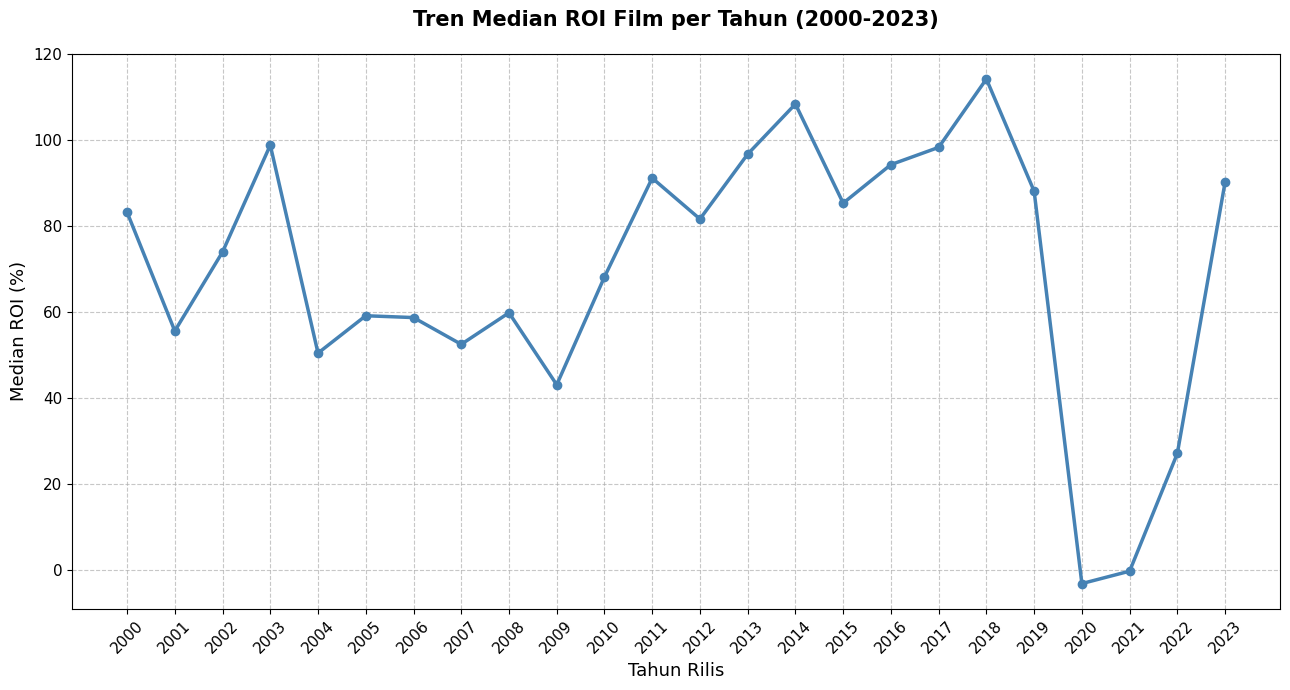

In [10]:
import matplotlib.pyplot as plt

median_roi_per_year = df.groupby('release_year')['ROI'].median().reset_index()

plt.figure(figsize=(13, 7))

plt.plot(median_roi_per_year['release_year'], 
         median_roi_per_year['ROI'], 
         marker='o', 
         color='steelblue', 
         linewidth=2.5, 
         markersize=6)

plt.title('Tren Median ROI Film per Tahun (2000-2023)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tahun Rilis', fontsize=13)
plt.ylabel('Median ROI (%)', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(median_roi_per_year['release_year'], rotation=45, fontsize=11)  # biar tahun tidak overlap
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
df['release_year'].value_counts().sort_index()

release_year
2000    171
2001    193
2002    215
2003    212
2004    247
2005    254
2006    287
2007    303
2008    291
2009    314
2010    325
2011    317
2012    292
2013    333
2014    316
2015    303
2016    337
2017    312
2018    262
2019    239
2020    114
2021    147
2022    148
2023    114
Name: count, dtype: int64

**Insight:** Tren median ROI film periode 2000–2023 menunjukkan fluktuasi, dengan puncak pada tahun 2018 dan penurunan tajam pada tahun 2020 yang kemungkinan besar dipengaruhi oleh pandemi COVID-19. Setelah itu, ROI kembali meningkat pada periode 2022–2023. Namun perlu dicatat bahwa jumlah film yang dirilis pada periode tersebut juga menurun, sehingga hasil ini perlu diinterpretasikan dengan hati-hati.

### 2. Distribusi ROI Film Secara Keseluruhan

In [12]:
df['ROI'].describe()

count    6046.00
mean      300.71
std      1990.69
min       -99.93
25%       -37.50
50%        72.35
75%       256.54
max     89832.93
Name: ROI, dtype: float64

**Ringkasan Statistik Deskriptif:**

- **Gap Min–Max yang ekstrem:** Jarak antara nilai terkecil (−99,93%) dan terbesar (89.832%) sangat jauh, menunjukkan variasi yang tinggi.
- **Data sangat variatif:** Standar deviasi (1.990,69) jauh lebih tinggi dibanding nilai rata-rata (300,71), mengindikasikan sebaran data yang tidak merata.
- **Distribusi Right-Skewed:** Nilai mean (300,71) jauh di atas median (72,35), menandakan distribusi yang condong ke kanan akibat beberapa film dengan ROI sangat tinggi.

Text(0, 0.5, 'Frekuensi (Jumlah Film)')

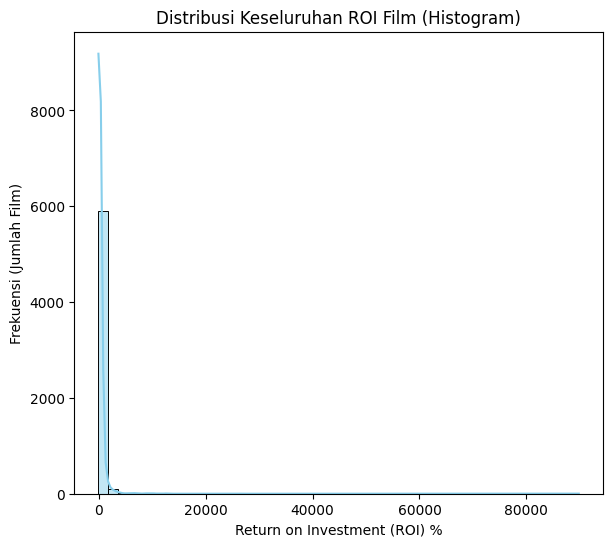

In [13]:
import seaborn as sns


plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['ROI'], bins=50, kde=True, color='skyblue')
plt.title('Distribusi Keseluruhan ROI Film (Histogram)')
plt.xlabel('Return on Investment (ROI) %')
plt.ylabel('Frekuensi (Jumlah Film)')

**Catatan:** Pada histogram, data tampak terkonsentrasi di ujung kiri. Ini bukan error — melainkan karena skala grafik tertarik jauh ke kanan untuk mengakomodasi film-film dengan ROI ekstrem. Kondisi ini konsisten dengan karakteristik distribusi right-skewed.

**Insight:** Distribusi ROI bersifat right-skewed — mayoritas film menghasilkan keuntungan yang relatif rendah, namun segelintir film dengan ROI ekstrem menarik nilai rata-rata jauh ke atas. Hal ini menunjukkan bahwa industri film didominasi oleh film-film dengan performa moderat, dengan peluang ROI sangat tinggi yang bersifat tidak merata.

### 3. Production Company dengan ROI Tertinggi

In [55]:
df_prod_grouped = (
    df_production
    .groupby('production_list')['ROI']
    .agg(['mean', 'median', 'count'])
)

df_prod_filtered = df_prod_grouped[df_prod_grouped['count'] >= 50]  # bisa 30/50
df_prod_filtered.sort_values(by='median', ascending=False).head(10)


,mean,median,count
production_list,,,
Blumhouse Productions,3383.59,1029.84,65
Fox Searchlight Pictures,696.19,198.15,70
Working Title Films,267.20,189.31,65
Screen Gems,331.23,187.54,75
Sony Pictures,229.18,178.27,53
New Line Cinema,580.51,173.87,156
Dune Entertainment,286.92,172.34,69
Walt Disney Pictures,228.05,164.50,147
Dimension Films,244.70,163.43,56


In [60]:
df_prod_grouped = (
    df_production
    .groupby('production_list')['ROI']
    .agg(['mean', 'median', 'count'])
)

df_prod_filtered = df_prod_grouped[df_prod_grouped['count'] >= 50]

# ambil top 10
top10 = (
    df_prod_filtered
    .sort_values(by='median', ascending=False)
    .head(10)
    .reset_index()
)




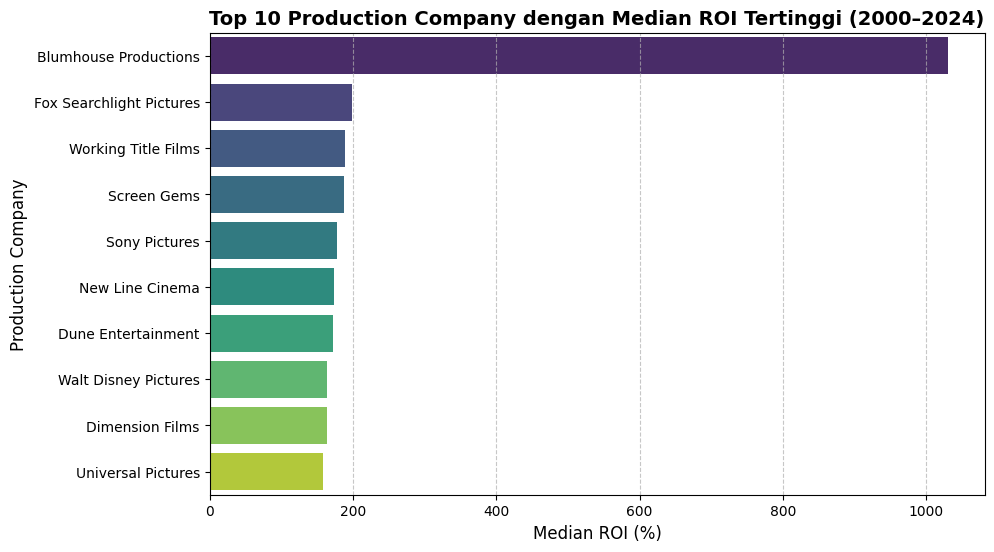

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='median', y='production_list', hue='production_list', palette='viridis', legend=False)

plt.title('Top 10 Production Company dengan Median ROI Tertinggi (2000–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Median ROI (%)', fontsize=12)
plt.ylabel('Production Company', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

**Insight:** Blumhouse Productions secara konsisten memiliki median ROI tertinggi dibandingkan production company lainnya, dengan selisih yang cukup signifikan. Hal ini menunjukkan bahwa model produksi Blumhouse — yang dikenal berfokus pada film berbudget rendah dengan potensi pendapatan tinggi — terbukti efektif secara finansial.

### 4. Genre Film dengan ROI Tertinggi

In [17]:
df_genre.groupby('genres_list')['ROI'].agg(['mean', 'median','count']).sort_values(by='mean', ascending=False)

,mean,median,count
genres_list,,,
Documentary,979.84,149.05,94
Horror,792.86,106.40,664
Music,762.13,92.31,191
Mystery,499.75,57.29,508
TV Movie,404.30,132.14,8
Thriller,325.73,61.28,1542
Family,275.35,109.99,659
Comedy,256.36,97.16,2164
Drama,248.12,41.34,2829


In [18]:
median_genre = df_genre.groupby('genres_list')['ROI'].median().sort_values(ascending=False).reset_index() ## menggunakan median karena roi per genresnya sangat skewed ke kanan

C:\Users\rinal\AppData\Local\Temp\ipykernel_34544\1698540546.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_genre.head(10), x='ROI', y='genres_list', palette='viridis')


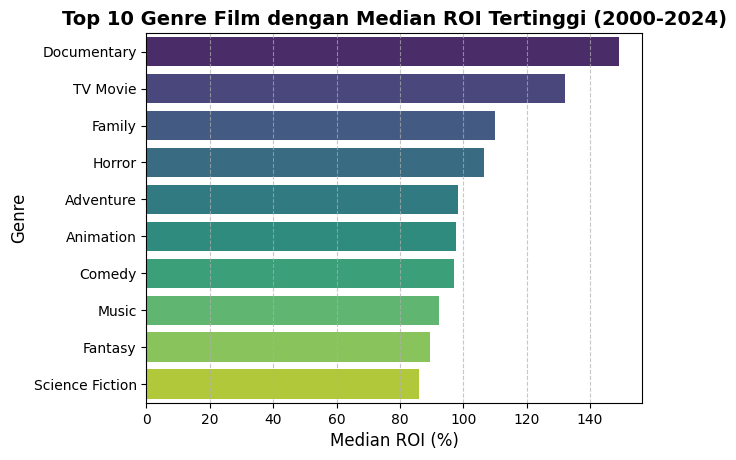

In [19]:
sns.barplot(data=median_genre.head(10), x='ROI', y='genres_list', palette='viridis')

plt.title('Top 10 Genre Film dengan Median ROI Tertinggi (2000-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Median ROI (%)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

**Insight:** Berdasarkan median ROI per genre, film Documentary dan TV Movie menempati posisi tertinggi dibandingkan genre lainnya. Hal ini mengindikasikan bahwa kedua genre tersebut cenderung lebih efisien secara produksi. Namun perlu diperhatikan bahwa jumlah film dalam kedua genre ini lebih sedikit dibanding genre lain, sehingga hasilnya perlu diinterpretasikan dengan hati-hati.

### 5. Hubungan antara Budget dan ROI

In [20]:
from scipy.stats import spearmanr
corr, p_value = spearmanr (df["budget"], df["ROI"]) 

print("Correlation:", corr)

print("p-value:", p_value)

Correlation: 0.039433109106923186
p-value: 0.002164209732112232


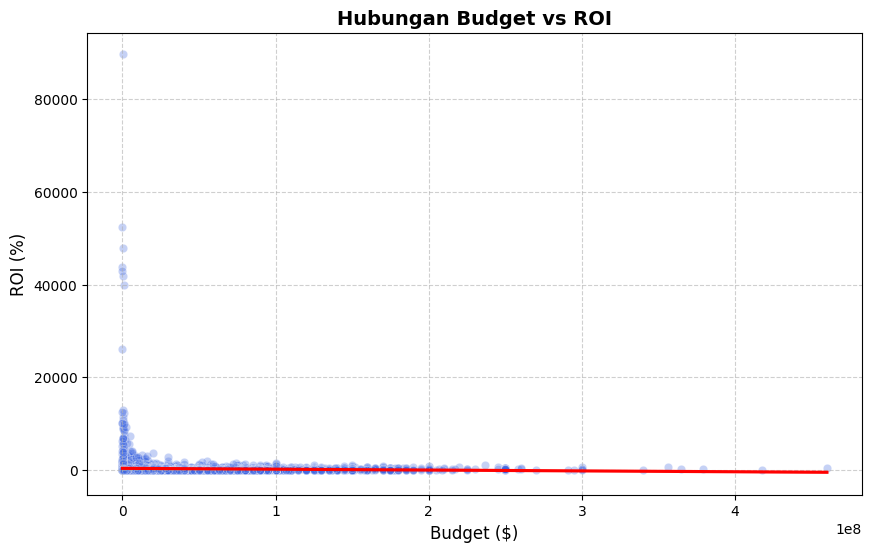

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='budget', y='ROI', alpha=0.3, color='royalblue')
sns.regplot(data=df, x='budget', y='ROI', scatter=False, color='red')


plt.title('Hubungan Budget vs ROI', fontsize=14, fontweight='bold')
plt.xlabel('Budget ($)', fontsize=12)
plt.ylabel('ROI (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Insight:** Meskipun terdapat hubungan positif antara budget dan ROI, nilai korelasi yang sangat kecil menunjukkan bahwa hubungan tersebut tidak kuat secara praktis. Artinya, budget bukan faktor penentu utama dalam menentukan tinggi rendahnya ROI sebuah film.

### 6. Perbedaan ROI Antar Genre (Uji Statistik)

In [35]:
from scipy import stats

genre1 = df_genre['ROI'][df_genre['genres_list']=='Action']
genre2 = df_genre['ROI'][df_genre['genres_list']=='Science Fiction']
genre3 = df_genre['ROI'][df_genre['genres_list']=='Drama']
genre4 = df_genre['ROI'][df_genre['genres_list']=='Adventure']
genre5 = df_genre['ROI'][df_genre['genres_list']=='Crime']
genre6 = df_genre['ROI'][df_genre['genres_list']=='Thriller']
genre7 = df_genre['ROI'][df_genre['genres_list']=='Fantasy']
genre8 = df_genre['ROI'][df_genre['genres_list']=='Comedy']
genre9 = df_genre['ROI'][df_genre['genres_list']=='Western']
genre10 = df_genre['ROI'][df_genre['genres_list']=='Mystery']
genre11 = df_genre['ROI'][df_genre['genres_list']=='War']
genre12 = df_genre['ROI'][df_genre['genres_list']=='Animation']
genre13 = df_genre['ROI'][df_genre['genres_list']=='Family']
genre14 = df_genre['ROI'][df_genre['genres_list']=='Horror']
genre15 = df_genre['ROI'][df_genre['genres_list']=='Music']
genre16 = df_genre['ROI'][df_genre['genres_list']=='History']
genre17 = df_genre['ROI'][df_genre['genres_list']=='Romance']
genre18 = df_genre['ROI'][df_genre['genres_list']=='Documentary']
genre19 = df_genre['ROI'][df_genre['genres_list']=='TV Movie']

res = stats.kruskal(genre1,genre2,genre3,genre4,genre5,genre6,genre7,genre8,genre9,genre10,genre11,genre12,genre13,genre14,genre15,genre16,genre17,genre18,genre19)
print('P-value:',res.pvalue)
p_value = res.pvalue

if p_value < 0.05:
    print("\nKesimpulan: P-value < 0.05 (Tolak H0).")
    print("Artinya: Terdapat perbedaan ROI yang SIGNIFIKAN secara statistik antar genre film.")
else:
    print("\nKesimpulan: P-value >= 0.05 (Gagal Tolak H0).")
    print("Artinya: Tidak ada perbedaan signifikan. Perbedaan di visualisasi mungkin hanya kebetulan.")

P-value: 2.1625490342118944e-31

Kesimpulan: P-value < 0.05 (Tolak H0).
Artinya: Terdapat perbedaan ROI yang SIGNIFIKAN secara statistik antar genre film.


In [ ]:
H = res.statistic
k = df_genre['genres_list'].nunique()
n = len(df_genre)

epsilon_squared = (H - k + 1) / (n - k)

print("Epsilon Squared:", epsilon_squared)

**Insight:** Meskipun terdapat perbedaan ROI antar genre yang signifikan secara statistik (Kruskal-Wallis), nilai effect size (Epsilon Squared ≈ 0,01) menunjukkan bahwa kekuatan pengaruh genre terhadap ROI sangat kecil. Dengan demikian, genre bukan merupakan faktor utama dalam menentukan ROI sebuah film.

#### Analisis Pendukung — Uji Statistik Production Company (untuk pertanyaan no. 3)

In [63]:
groups = [
    group['ROI'].values
    for name, group in df_production.groupby('production_list')
]

res = stats.kruskal(*groups)

print("P-value:", res.pvalue)
H = res.statistic
k = df_production['production_list'].nunique()
n = len(df_production)

epsilon_squared = (H - k + 1) / (n - k)

print("Epsilon Squared:", epsilon_squared)

P-value: 8.813080605760264e-123
Epsilon Squared: 0.22643741809273124


**Insight:** Terdapat perbedaan ROI antar production company yang signifikan secara statistik, dengan nilai effect size yang relatif lebih kuat dibanding genre. Hal ini memperkuat temuan bahwa production company merupakan salah satu faktor yang lebih berpengaruh terhadap ROI dibandingkan genre maupun budget.

## Kesimpulan dan Rekomendasi

### Kesimpulan

Tren median ROI film periode 2000–2023 menunjukkan fluktuasi yang cukup signifikan, sehingga investor perlu berhati-hati dalam memasuki industri ini.

Dalam industri film, mayoritas film menghasilkan keuntungan yang relatif rendah. Namun terdapat sejumlah film "abnormal" dengan ROI sangat tinggi — umumnya film berbudget kecil yang meraih pendapatan jauh di atas ekspektasi.

Meskipun terdapat perbedaan ROI antar genre secara statistik, nilai effect size yang sangat kecil menunjukkan bahwa genre tidak memiliki pengaruh yang berarti terhadap tinggi rendahnya ROI.

Begitu pula dengan budget — meskipun terdapat korelasi positif, kekuatan hubungannya sangat lemah sehingga budget bukan faktor penentu ROI yang dapat diandalkan.

Dari sisi production company, terdapat perbedaan ROI yang cukup besar antar perusahaan, dengan kekuatan hubungan yang lebih signifikan secara statistik. Hal ini menjadikan production company sebagai faktor yang lebih relevan untuk dipertimbangkan.

Secara keseluruhan, ROI film tidak hanya ditentukan oleh genre dan budget. Production company terbukti menjadi faktor yang lebih berpengaruh, sementara kemungkinan besar masih terdapat faktor lain di luar data — seperti kualitas naskah dan pemilihan pemain — yang turut memengaruhi hasil akhir.

### Rekomendasi Praktis

Bagi investor yang ingin memaksimalkan potensi ROI, strategi yang lebih rasional adalah memahami karakteristik dan pola produksi dari production company dengan rekam jejak median ROI tinggi — seperti Blumhouse Productions. Pendekatan ini lebih dapat diandalkan dibandingkan sekadar mengikuti tren genre tertentu atau berfokus pada kisaran budget tertentu. Selain itu, faktor-faktor kualitatif seperti kualitas naskah dan pemilihan pemain tetap perlu dipertimbangkan sebagai bagian dari keputusan investasi.

In [64]:
# Ekspor dataframe hasil cleaning untuk keperluan visualisasi di Tableau
df.to_csv('film_roi.csv', index=False)
df_genre.to_csv('genre_roi.csv', index=False)
df_production.to_csv('production.csv', index=False)